# Computational Modeling

Objectives

1. Construct a computational model capable of reproducing the empirical reaction-time patterns observed in the Stroop task.

2. Represent reaction time as the combination of baseline processing speed, condition-specific cognitive costs, and stochastic variability.

3. Evaluate whether a simple interference mechanism is sufficient to reproduce observed condition means and effect sizes.

4. Compare simulated and empirical data using quantitative goodness-of-fit metrics.

5. Assess the strengths and limitations of the model as an explanation of Stroop interference.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Figure Style

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["figure.autolayout"] = True
plt.rcParams["font.size"] = 11
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["savefig.bbox"] = "tight"

palette = {
    "congruent": "#4E79A7",
    "neutral": "#9E9E9E",
    "incongruent": "#E15759",
    "real": "#4E79A7",
    "simulated": "#E15759",
}

In [2]:
np.random.seed(1)

In [3]:
# Loading clean data.

df = pd.read_csv(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\data\processed\stroop-cleaned.csv")

In [4]:
# Defining model parameters.

baseline_rt = 0.67
neutral_cost = 0.02
interference_cost = 0.10633
noise_sd = 0.22

Note: model parameters were derived from empirical conditions.

In [5]:
# Defining number of simulated trials.

n_trials = 10000

In [6]:
# Generating conditions.

conditions = np.random.choice(
    ["congruent", "neutral", "incongruent"],
    size=n_trials
)

In [7]:
# Simulating RTs.

rts = []

for condition in conditions:

    rt = baseline_rt

    rt += np.random.normal(
        loc=0,
        scale=noise_sd
    )

    if condition == "incongruent":
        rt += interference_cost

    if condition == "neutral":
        rt += neutral_cost

    rts.append(rt)

In [8]:
# Creating simulated dataset.

simulated = pd.DataFrame({
    "condition": conditions,
    "RT": rts
})

print(simulated.head())

   condition        RT
0    neutral  0.368434
1  congruent  0.171797
2  congruent  0.192118
3    neutral  0.870533
4    neutral -0.047563


In [9]:
# Verifying qualitative pattern.

simulated.groupby("condition")["RT"].mean()

condition
congruent      0.672541
incongruent    0.776113
neutral        0.699307
Name: RT, dtype: float64

In [10]:
# Verifying effect size.

means = simulated.groupby("condition")["RT"].mean()

effect = (means["incongruent"] - means["congruent"])

print(effect)

0.10357225302335371


In [11]:
# Saveing simulation output.

simulated.to_csv(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\results\simulated-data.csv", index=False)

## Minimal Computational Model

A simple interference model was created to reproduce the qualitative Stroop pattern.

The model assumes that reaction time is generated by three components:

> RT = baseline processing speed + random noise + interference cost

Note: for incongruent trials, I added a fixed interference cost to the baseline reaction time.

The simulation successfully reproduced the expected pattern, with incongruent trials producing slower reaction times than congruent trials.

The purpose of this model is not parameter fitting or prediction. It demonstrates how a simple cognitive mechanism can generate the empirical pattern of the Stroop task.

In [12]:
# Comparing model and empirical data.

# Computing empirical means.

real_means = (
    df.groupby("condition")["RT"]
    .mean()
)

print("Empirical mean:\n", real_means)

# Computing simulated means.

sim_means = (
    simulated.groupby("condition")["RT"]
    .mean()
)

print("\nSimulated mean:\n", sim_means)

# Creating comparison table.

comparison = pd.DataFrame({
    "real": real_means,
    "simulated": sim_means
})

print("\nComparison table:\n", comparison)

Empirical mean:
 condition
congruent      0.673524
incongruent    0.777733
neutral        0.689851
Name: RT, dtype: float64

Simulated mean:
 condition
congruent      0.672541
incongruent    0.776113
neutral        0.699307
Name: RT, dtype: float64

Comparison table:
                  real  simulated
condition                       
congruent    0.673524   0.672541
incongruent  0.777733   0.776113
neutral      0.689851   0.699307


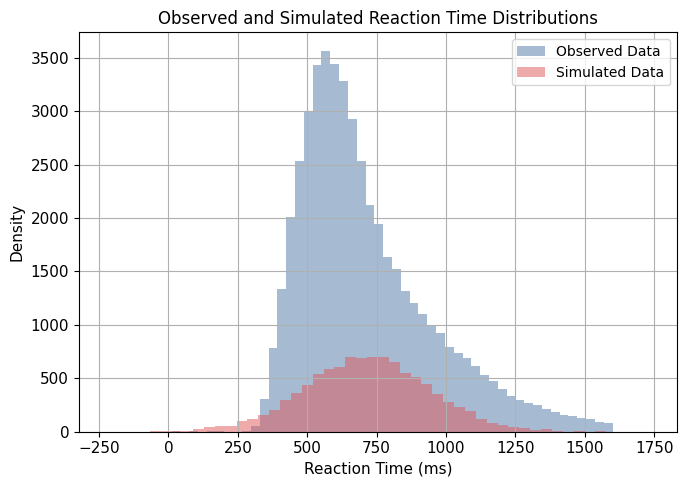

In [13]:
# Creating distribution figure.

plt.figure()

(df["RT"] * 1000).hist(
    bins=50,
    alpha=0.5,
    color=palette["real"],
    label="Observed Data"
)

(simulated["RT"] * 1000).hist(
    bins=50,
    alpha=0.5,
    color=palette["simulated"],
    label="Simulated Data"
)

plt.xlabel("Reaction Time (ms)")
plt.ylabel("Density")
plt.title("Observed and Simulated Reaction Time Distributions")

plt.legend()

plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\model-vs-data.png")
plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\model-vs-data.pdf")

plt.show()